[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giuliofranzese/Cajal/blob/main/soi/notebook.ipynb)

# SΩI: Score-based O-INFORMATION Estimation — Quickstart

This notebook follows the ideas from the paper **"SΩI: Score-based O-INFORMATION Estimation"** (Bounoua et al., 2024, [arXiv:2402.05667](https://arxiv.org/pdf/2402.05667)).

## What is O-information?
For a multivariate system $X = (X^1, \dots, X^n)$, the O-information is:

$$
\Omega(X) = \mathrm{TC}(X) - \mathrm{DTC}(X)
$$

where:
- $\mathrm{TC}$ (total correlation) quantifies overall statistical dependence,
- $\mathrm{DTC}$ (dual total correlation) captures dependence from a complementary perspective.

Interpretation used in the paper:
- **$\Omega(X) > 0$**: redundancy-dominated interactions,
- **$\Omega(X) < 0$**: synergy-dominated interactions,
- **$\Omega(X) \approx 0$**: balanced or weak higher-order structure.

SΩI estimates these quantities by learning score functions with diffusion models, avoiding direct density estimation in high dimensions.

## 0. Setup: Clone repo and install dependencies

In [9]:
import logging
import os
import subprocess
import sys
import warnings

from tqdm import TqdmWarning

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("PIP_DISABLE_PIP_VERSION_CHECK", "1")

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", message=r".*pin_memory.*no accelerator is found.*")
warnings.filterwarnings("ignore", message=r".*Found .* module\(s\) in eval mode.*")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("lightning_fabric").setLevel(logging.ERROR)

# Some libraries inspect sys.argv inside notebooks and choke on Jupyter's -f kernel argument.
sys.argv = [sys.argv[0]]

import torch

# --- Environment detection ---
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    soi_repo_dir = "/content/soi_repo"
    # Install requirements inline (requirements.txt is not available in Colab)
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            "numpy>=1.24", "scipy>=1.10", "torch>=2.0",
            "pytorch_lightning>=2.2", "timm>=0.9", "tqdm>=4.60",
            "tensorboard>=2.14", "matplotlib>=3.7", "scikit-learn>=1.3",
        ],
        check=True,
    )
else:
    # Devcontainer: use requirements.txt next to this notebook
    _nb_dir = os.path.dirname(os.path.abspath("__file__"))
    soi_repo_dir = os.path.join(_nb_dir, "soi_repo")
    requirements_path = os.path.join(_nb_dir, "requirements.txt")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", requirements_path],
        check=True,
    )

print("Dependencies installed.")

# Clone the SOI repository if not already present
if not os.path.isdir(soi_repo_dir):
    subprocess.run(
        ["git", "clone", "https://github.com/MustaphaBounoua/soi.git", soi_repo_dir],
        check=True,
    )
    print("Repository cloned.")
else:
    print("Repository already cloned.")

# Add the repo root to sys.path so imports work
if soi_repo_dir not in sys.path:
    sys.path.insert(0, soi_repo_dir)

# Patch SDE.py to auto-detect CPU/GPU (upstream hardcodes 'cuda')
sde_path = os.path.join(soi_repo_dir, "src", "libs", "SDE.py")
with open(sde_path, "r") as f:
    sde_code = f.read()
if 'self.device = "cuda"' in sde_code:
    sde_code = sde_code.replace(
        'self.device = "cuda"',
        'self.device = "cuda" if torch.cuda.is_available() else "cpu"',
    )
    with open(sde_path, "w") as f:
        f.write(sde_code)
    print("Patched SDE.py for CPU/GPU auto-detection.")

print("Setup complete.")


Dependencies installed.
Repository already cloned.
Patched SDE.py for CPU/GPU auto-detection.
Setup complete.


## 1. Imports and default configuration

In [10]:
from experiments.config import get_default_config
from src.benchmark.synthetic_dataset import get_task, get_dataloader
from src.libs.soi import SOI
from src.libs.soi_grad import SOI_grad
import numpy as np

## Default config
args = get_default_config()

## 2. Synthetic Benchmarks

This section mirrors the experimental logic of the paper: build controlled synthetic systems where the interaction regime is known in advance, then verify whether O-information recovers the expected sign.

### How tasks are generated (experiment-style view)
The synthetic generators create multivariate systems from Gaussian constructions parameterized by:
- task type (redundancy vs synergy),
- number of variables in each subsystem,
- coupling strength $\rho$.

In this notebook we use small systems (3 variables per subsystem) for fast runs, while the broader benchmark family in the code also includes larger settings such as [3,3,4] and [3,3], consistent with the paper's experimental protocol.

### Redundancy benchmark
A synthetic task with 3 variables exhibiting **redundancy** (rho=0.6).

Construction intuition: variables are driven by overlapping/shared statistical sources, so information tends to be repeated across variables. Expected signature: $\Omega(X) > 0$.

In [11]:
## Redundancy task: 3 variables
my_settings = [{"rho": 0.6, "type": "red", "nb": 3}]
args.dim = 1
task_red = get_task(args, my_settings)
task_red.o_inf()

np.float64(0.1473686022506091)

### Synergy benchmark
A synthetic task with 3 variables exhibiting **synergy** (rho=0.6).

Construction intuition: each variable alone is less informative, but combining variables reveals information that is not present in marginals. Expected signature: $\Omega(X) < 0$.

In [12]:
## Synergy task: 3 variables
my_settings = [{"rho": 0.6, "type": "syn", "nb": 3}]
args.dim = 1
task_syn = get_task(args, my_settings)
task_syn.get_summary()["o_inf"]

np.float64(-0.12391808195228782)

### Redundancy + Synergy (mixed) benchmark
A synthetic task with 6 variables: two subsystems of 3 variables each, one redundant and one synergistic.

This mixed design follows the same experimental motivation as in the paper: evaluate whether the estimator can recover competing higher-order structures in one system instead of a purely positive or purely negative O-information regime.

In [13]:
## Mixed task: 3 redundant + 3 synergistic variables
my_settings = [{"rho": 0.6, "type": "red", "nb": 3}, {"rho": 0.6, "type": "syn", "nb": 3}]
args.dim = 1
task_both = get_task(args, my_settings)
task_both.get_summary()["o_inf"]

np.float64(0.02345052029832928)

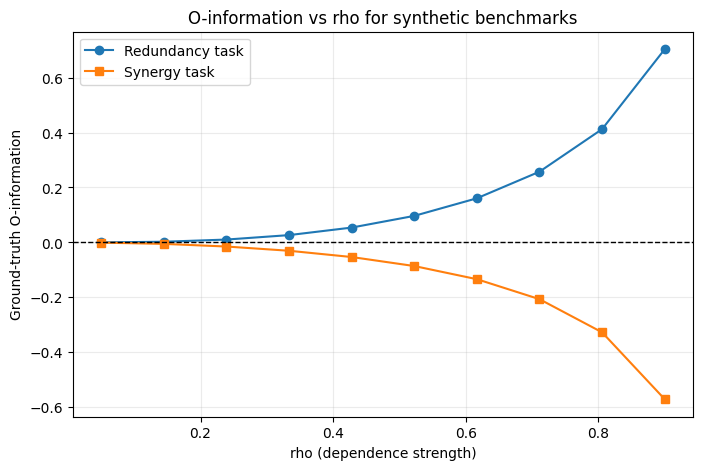

In [14]:
import matplotlib.pyplot as plt

rho_grid = np.linspace(0.05, 0.9, 10)
o_red, o_syn = [], []

for rho in rho_grid:
    red_task = get_task(args, [{"rho": float(rho), "type": "red", "nb": 3}])
    syn_task = get_task(args, [{"rho": float(rho), "type": "syn", "nb": 3}])
    o_red.append(red_task.get_summary()["o_inf"])
    o_syn.append(syn_task.get_summary()["o_inf"])

plt.figure(figsize=(8, 5))
plt.plot(rho_grid, o_red, marker="o", label="Redundancy task")
plt.plot(rho_grid, o_syn, marker="s", label="Synergy task")
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.xlabel("rho (dependence strength)")
plt.ylabel("Ground-truth O-information")
plt.title("O-information vs rho for synthetic benchmarks")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Reading the sensitivity plot
This sweep illustrates the benchmark design principles discussed in the paper:

- the **redundancy** benchmark tends to produce positive O-information,
- the **synergy** benchmark tends to produce negative O-information,
- increasing coupling strength $\rho$ generally increases the absolute magnitude $|\Omega|$.

In practice, finite-sample effects and estimator variance can create small deviations, but the sign pattern is the key diagnostic.

## 3. O-information Estimation with SΩI

### General configuration
We configure the model for a quick training run with EMA, importance sampling, and weighted score functions.

In [15]:
args.use_ema = True
args.weight_s_functions = True
args.importance_sampling = True
args.bs = 512
args.warmup_epochs = 30
args.max_epochs = 50
args.test_epoch = 5
args.debug = True
args.out_dir = "quickstart/"
args.nb_workers = 0

# Use CPU-friendly defaults when no GPU is available
import torch
if not torch.cuda.is_available():
    args.accelerator = "cpu"
    args.devices = 1
    args.N = 5000
    args.N_test = 2000
    args.bs = 256
    args.warmup_epochs = 1
    args.max_epochs = 3
    args.test_epoch = 1
    args.check_val_every_n_epoch = 1
    args.mc_iter = 2

### Running SΩI on the redundancy benchmark

In [16]:
gt = task_red.get_summary()
train_l, test_l = get_dataloader(task_red, args)

## Instantiate SOI
soi = SOI(args, nb_var=task_red.nb_var, gt=gt)
## Fit the model
soi.fit(train_l, test_l)
## Compute O-information using the test loader
results = soi.compute_o_inf()

print("SOI:", {"O-inf": results["o_inf"], "tc": results["tc"], "dtc": results["dtc"], "S-info": results["s_inf"]})
print("GT: ", {"O-inf": gt["o_inf"], "tc": gt["tc"], "dtc": gt["dtc"], "S-info": gt["s_inf"]})

Weighting the scores to learn 
Epoch:  2  GT:  0.147 SOI_estimate:  -0.006
SOI: {'O-inf': np.float64(-0.005579148884862661), 'tc': np.float64(0.01105624670162797), 'dtc': np.float64(0.01663539558649063), 'S-info': np.float64(0.0276916422881186)}
GT:  {'O-inf': np.float64(0.1473686022506091), 'tc': np.float64(0.52206205169202), 'dtc': np.float64(0.3746934494414109), 'S-info': np.float64(0.8967555011334309)}


### Running SΩI on the synergy benchmark

In [17]:
gt = task_syn.get_summary()
train_l, test_l = get_dataloader(task_syn, args)

## Instantiate SOI
soi = SOI(args, nb_var=task_syn.nb_var, gt=gt)
## Fit the model
soi.fit(train_l, test_l)
## Compute O-information using the test loader
results = soi.compute_o_inf()

print("SOI:", {"O-inf": results["o_inf"], "tc": results["tc"], "dtc": results["dtc"], "S-info": results["s_inf"]})
print("GT: ", {"O-inf": gt["o_inf"], "tc": gt["tc"], "dtc": gt["dtc"], "S-info": gt["s_inf"]})

Weighting the scores to learn 
Epoch:  2  GT:  -0.124 SOI_estimate:  -0.004
SOI: {'O-inf': np.float64(-0.0036536564584821463), 'tc': np.float64(0.004064435139298439), 'dtc': np.float64(0.007718091597780585), 'S-info': np.float64(0.011782526737079024)}
GT:  {'O-inf': np.float64(-0.12391808195228782), 'tc': np.float64(0.5697171415941797), 'dtc': np.float64(0.6936352235464676), 'S-info': np.float64(1.2633523651406473)}


### Running SΩI on the mixed (redundancy + synergy) benchmark

In [18]:
gt = task_both.get_summary()
train_l, test_l = get_dataloader(task_both, args)

## More epochs for the mixed benchmark
if torch.cuda.is_available():
    args.warmup_epochs = 60
    args.max_epochs = 80
else:
    args.warmup_epochs = 1
    args.max_epochs = 3

## Instantiate SOI
soi = SOI(args, nb_var=task_both.nb_var, gt=gt)
## Fit the model
soi.fit(train_l, test_l)
## Compute O-information using the test loader
results = soi.compute_o_inf()

print("SOI:", {"O-inf": results["o_inf"], "tc": results["tc"], "dtc": results["dtc"], "S-info": results["s_inf"]})
print("GT: ", {"O-inf": gt["o_inf"], "tc": gt["tc"], "dtc": gt["dtc"], "S-info": gt["s_inf"]})

Weighting the scores to learn 
Epoch:  2  GT:  0.023 SOI_estimate:  -0.006
SOI: {'O-inf': np.float64(-0.005788024282082915), 'tc': np.float64(0.006019372260197997), 'dtc': np.float64(0.011807396542280912), 'S-info': np.float64(0.01782676880247891)}
GT:  {'O-inf': np.float64(0.02345052029832928), 'tc': np.float64(1.0917791932861967), 'dtc': np.float64(1.0683286729878674), 'S-info': np.float64(2.160107866274064)}


## 4. Gradients of O-information Estimation

The gradient contribution for variable $X^i$ is based on the paper's idea of measuring the impact of removing one variable:

$$
g_{\Omega}(X^i) = \Omega(X) - \Omega(X_{\setminus i})
$$

Interpretation:
- positive contribution: variable supports redundancy-dominated structure,
- negative contribution: variable supports synergy-dominated structure,
- larger magnitude: stronger structural role.

This is useful when total O-information is near zero but hidden opposing effects exist across groups of variables.

In [19]:
## Ground truth gradients of O-information
gt = task_both.get_summary()
print("Ground truth g_o_inf:", " ".join([
    "x{}: {},".format(i, np.round(x, decimals=3)) for i, x in enumerate(gt["g_o_inf"])
]))

Ground truth g_o_inf: x0: 0.147, x1: 0.147, x2: 0.147, x3: -0.124, x4: -0.124, x5: -0.124,


### Sensitivity Study for Gradient O-information
We now vary the benchmark parameter $\rho$ and track how gradient contributions evolve.

Protocol:
- build a mixed task (3 redundant + 3 synergistic variables) for each $\rho$,
- extract ground-truth $g_{\Omega}$ from the generator,
- visualize both per-variable trajectories and group averages.

Expected behavior:
- redundant-group variables tend to have positive contributions,
- synergistic-group variables tend to have negative contributions,
- contribution magnitude generally increases with coupling strength.

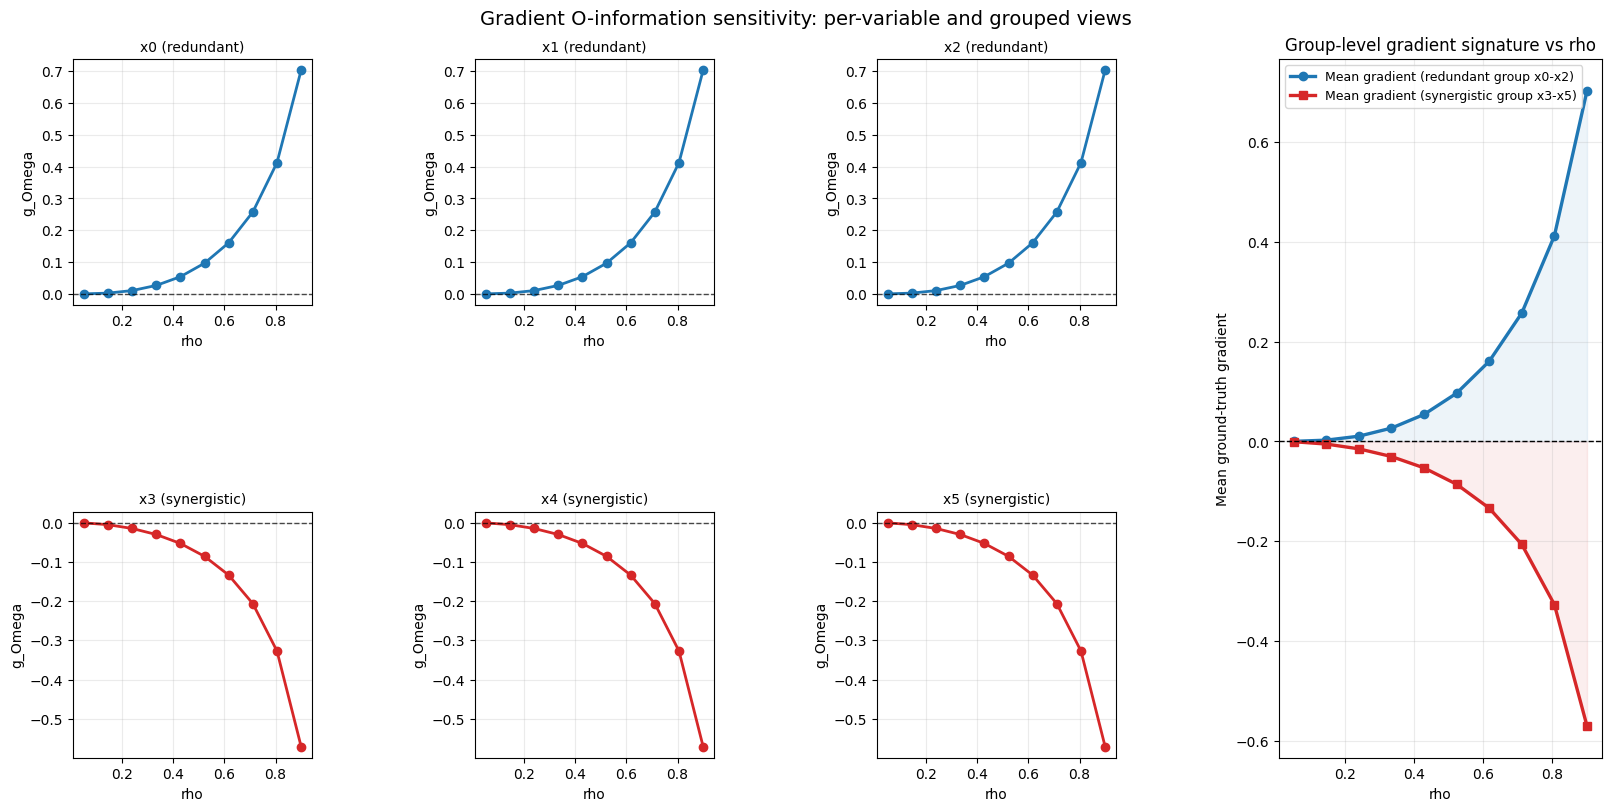

In [23]:
import matplotlib.pyplot as plt

rho_grid_grad = np.linspace(0.05, 0.9, 10)
grad_by_var = {f"x{i}": [] for i in range(6)}
grad_red_mean, grad_syn_mean = [], []

for rho in rho_grid_grad:
    task_mix_rho = get_task(args, [
        {"rho": float(rho), "type": "red", "nb": 3},
        {"rho": float(rho), "type": "syn", "nb": 3},
    ])
    gt_mix = task_mix_rho.get_summary()
    gvals = np.array(gt_mix["g_o_inf"], dtype=float)

    for i in range(6):
        grad_by_var[f"x{i}"].append(gvals[i])

    grad_red_mean.append(np.mean(gvals[:3]))
    grad_syn_mean.append(np.mean(gvals[3:]))

# --- Improved layout for readability: small multiples + group summary ---
fig = plt.figure(figsize=(16, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 1.35], wspace=0.25, hspace=0.18)

var_axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]
ax_group = fig.add_subplot(gs[:, 3])

red_color = "#1f77b4"
syn_color = "#d62728"

for i, ax in enumerate(var_axes):
    series = grad_by_var[f"x{i}"]
    color = red_color if i < 3 else syn_color
    group_name = "redundant" if i < 3 else "synergistic"

    ax.plot(rho_grid_grad, series, color=color, marker="o", linewidth=2)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.grid(alpha=0.25)
    ax.set_title(f"x{i} ({group_name})", fontsize=10)
    ax.set_xlabel("rho")
    ax.set_ylabel("g_Omega")

# Group-level summary panel
ax_group.plot(rho_grid_grad, grad_red_mean, marker="o", linewidth=2.4, color=red_color,
              label="Mean gradient (redundant group x0-x2)")
ax_group.plot(rho_grid_grad, grad_syn_mean, marker="s", linewidth=2.4, color=syn_color,
              label="Mean gradient (synergistic group x3-x5)")
ax_group.fill_between(rho_grid_grad, grad_red_mean, 0, color=red_color, alpha=0.08)
ax_group.fill_between(rho_grid_grad, grad_syn_mean, 0, color=syn_color, alpha=0.08)
ax_group.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax_group.set_title("Group-level gradient signature vs rho", fontsize=12)
ax_group.set_xlabel("rho")
ax_group.set_ylabel("Mean ground-truth gradient")
ax_group.grid(alpha=0.25)
ax_group.legend(fontsize=9, loc="upper left")

fig.suptitle("Gradient O-information sensitivity: per-variable and grouped views", fontsize=14)
plt.show()

In [20]:
## Run SOI with gradient of O-information estimation
if torch.cuda.is_available():
    args.warmup_epochs = 80
    args.max_epochs = 100
else:
    args.warmup_epochs = 1
    args.max_epochs = 3
    args.mc_iter = 2

gt = task_both.get_summary()
train_l, test_l = get_dataloader(task_both, args)

## Instantiate SOI_grad (extends SOI with gradient estimation)
soi = SOI_grad(args, nb_var=task_both.nb_var, gt=gt)
## Fit the model
soi.fit(train_l, test_l)
## Compute O-information with gradients
print("Final estimation:", soi.compute_o_inf_with_grad())

Weighting the scores to learn 
O_inf - GT:  0.023 O_inf - SOI_new:  -0.01
Gradient O_inf - GT:  x0: 0.147, x1: 0.147, x2: 0.147, x3: -0.124, x4: -0.124, x5: -0.124,
Gradient O_inf - SOI: x0: -0.006, x1: -0.007, x2: -0.004, x3: -0.004, x4: -0.004, x5: -0.003,


SystemExit: 1

/home/codespace/.local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
